In [ ]:
import torch
from torchvision import transforms
from torchvision.datasets import ImageFolder
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt

In [3]:
# dataset paths
PROJECT_ROOT = Path.cwd().parent
DATASET_DIR = PROJECT_ROOT/"datasets"/"raw"/"astro_dataset_maxia"

TRAIN_DIR = DATASET_DIR/"training"
VAL_DIR = DATASET_DIR/"validation"
TEST_DIR = DATASET_DIR/"test"

In [7]:
classes = sorted(
    [
        folder.name
        for folder in TRAIN_DIR.iterdir()
        if folder.is_dir()
    ]
)
print(classes)

['asteroid', 'black_hole', 'earth', 'galaxy', 'jupiter', 'mars', 'mercury', 'neptune', 'pluto', 'saturn', 'uranus', 'venus']


In [9]:
# decode image size
IMAGE_SIZE = (224, 224)

In [19]:
# preprocessing pipeline
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)
])

In [20]:
# testing the pipeline
sample_image_path = next((TRAIN_DIR/classes[0]).glob("*"))
print(sample_image_path)

# open the image
image = Image.open(sample_image_path)
print(image)

d:\cosmolens-ai-space-identifier\datasets\raw\astro_dataset_maxia\training\asteroid\asteroid_page_1_image_10_0_SwinIR_large.png
<PIL.PngImagePlugin.PngImageFile image mode=RGB size=2048x2048 at 0x1F05D949E50>


In [22]:
# applying the pipeline
processed_image = transform(image)
print(processed_image.shape)

torch.Size([3, 224, 224])


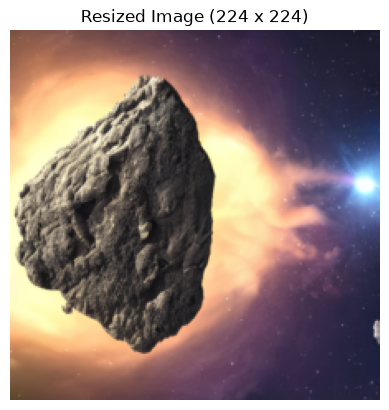

In [24]:
# visualize the transformed image
display_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor()
])
display_image = display_transform(image)

# display the image
plt.imshow(display_image.permute(1, 2, 0))
plt.axis("off")
plt.title("Resized Image (224 x 224)")
plt.show()

In [27]:
# creating the training dataset
train_dataset = ImageFolder(
    root = TRAIN_DIR,
    transform = transform
)

# verify
print(len(train_dataset))

2416


In [29]:
# class mapping
print(train_dataset.class_to_idx)

{'asteroid': 0, 'black_hole': 1, 'earth': 2, 'galaxy': 3, 'jupiter': 4, 'mars': 5, 'mercury': 6, 'neptune': 7, 'pluto': 8, 'saturn': 9, 'uranus': 10, 'venus': 11}


In [35]:
from torch.utils.data import DataLoader
# create training DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size = 32,
    shuffle = True
)

# verify
images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [46]:
# denormalization function
def denormalize(image_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    image_tensor = image_tensor  * std + mean
    image_tensor = torch.clamp(image_tensor, 0, 1)
    return image_tensor

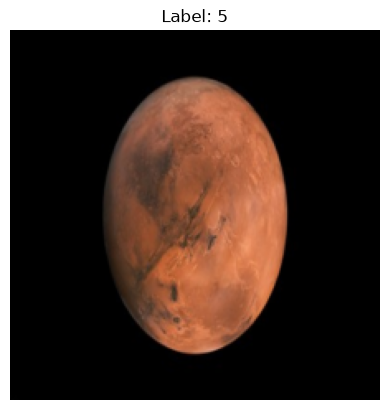

In [47]:
# display image
image = denormalize(images[0])
image = image.permute(1, 2, 0)
plt.imshow(image)
plt.axis("off")
plt.title(f"Label: {labels[0].item()}")
plt.show()

In [48]:
# convert label number to class name
idx_to_class = {
    value: key 
    for key, value in train_dataset.class_to_idx.items()
}

print(idx_to_class)

{0: 'asteroid', 1: 'black_hole', 2: 'earth', 3: 'galaxy', 4: 'jupiter', 5: 'mars', 6: 'mercury', 7: 'neptune', 8: 'pluto', 9: 'saturn', 10: 'uranus', 11: 'venus'}


# Conclusion

## Objective
To clean and preprocess the astronomy dataset before model training.

## What We Did
- Removed corrupted or unreadable images.
- Verified image formats.
- Standardized image loading.
- Prepared the dataset for PyTorch.

## Results
- Successfully cleaned the dataset.
- Eliminated invalid image files.
- Produced a consistent dataset for training.

## Key Learnings
- Data cleaning techniques.
- Image validation.
- Importance of preprocessing.
- Dataset consistency.

## Conclusion
A clean and consistent dataset was created, reducing potential training errors and improving model reliability.